In [2]:
from __future__ import annotations

from collections.abc import Mapping
from typing import Any, Callable, Optional, Sequence, Union

import numpy as np


In [3]:
def _masked_softmax_over_layers(S, keep_mask, *, temperature=1.0, eps=1e-12):
    """
    Softmax over the layer axis.

    S:         [N, L, T]
    keep_mask: [N, L, T] bool

    Returns:
        P: [N, L, T], where P[n, :, t] sums to 1 only if at least one layer survived.
           If no layer survived, P[n, :, t] is all zeros.
    """
    S = np.asarray(S, dtype=float)

    if temperature <= 0:
        raise ValueError("temperature must be > 0")

    X = S / temperature

    # Critical: masked-out entries must not receive softmax mass.
    X = np.where(keep_mask & np.isfinite(X), X, -np.inf)

    # Stable softmax over layer axis.
    valid_any = np.any(np.isfinite(X), axis=1, keepdims=True)  # [N, 1, T]

    max_x = np.max(X, axis=1, keepdims=True)
    max_x = np.where(valid_any, max_x, 0.0)

    exp_x = np.exp(X - max_x)
    exp_x = np.where(np.isfinite(X), exp_x, 0.0)

    denom = exp_x.sum(axis=1, keepdims=True)

    P = np.divide(
        exp_x,
        denom,
        out=np.zeros_like(exp_x),
        where=denom > eps,
    )

    return np.transpose(P, (0, 2, 1))


def weighted_median_layer(weights, layers=None):
    weights = np.asarray(weights, dtype=float)

    if layers is None:
        layers = np.arange(len(weights))
    else:
        layers = np.asarray(layers)

    # Important: weights must be non-negative
    weights = np.nan_to_num(weights, nan=0.0)
    weights = np.maximum(weights, 0.0)

    total = weights.sum()
    if total == 0:
        return np.nan

    order = np.argsort(layers)
    layers_sorted = layers[order]
    weights_sorted = weights[order]

    cumsum = np.cumsum(weights_sorted)
    cutoff = 0.5 * total

    return layers_sorted[np.searchsorted(cumsum, cutoff)]

def layer_location_stats(weights, layers=None):
    weights = np.asarray(weights, dtype=float)

    if layers is None:
        layers = np.arange(len(weights))
    else:
        layers = np.asarray(layers)

    weights = np.nan_to_num(weights, nan=0.0)
    weights = np.maximum(weights, 0.0)

    total = weights.sum()
    if total == 0:
        return {
            "layer_com": np.nan,
            "layer_median": np.nan,
            "layer_argmax": np.nan,
            "layer_argmax_value": np.nan,
        }

    layer_com = float(np.sum(layers * weights) / total)

    layer_median = weighted_median_layer(weights, layers)

    argmax_idx = int(np.argmax(weights))
    layer_argmax = int(layers[argmax_idx])
    layer_argmax_value = float(weights[argmax_idx])

    return {
        "layer_com": layer_com,
        "layer_median": layer_median,
        "layer_argmax": layer_argmax,
        "layer_argmax_value": layer_argmax_value,
    }

In [10]:

# =========================================================
# Basic helpers
# =========================================================

def _to_numpy(x: Any) -> np.ndarray:
    """Accept numpy arrays, lists, or torch tensors."""
    try:
        import torch
        if isinstance(x, torch.Tensor):
            return x.detach().cpu().numpy()
    except Exception:
        pass
    return np.asarray(x)


def _standardize_similarity(
    similarity: Any,
    input_layout: str = "NLT",
) -> np.ndarray:
    """
    Return similarity with shape [N, L, T].

    input_layout:
        "NLT": [concept, layer, epoch]
        "NTL": [concept, epoch, layer]
    """
    S = _to_numpy(similarity).astype(np.float64)

    if S.ndim != 3:
        raise ValueError(f"`similarity` must be 3D, got shape {S.shape}.")

    layout = input_layout.replace(",", "").replace(" ", "").upper()

    if layout == "NLT":
        return S
    if layout == "NTL":
        return np.transpose(S, (0, 2, 1))

    raise ValueError("`input_layout` must be either 'NLT' or 'NTL'.")


def _as_values(
    values: Optional[Sequence[float]],
    n: int,
    name: str,
) -> np.ndarray:
    """
    Convert epoch/layer values to increasing float array.

    If values is None:
        epochs default to 0, 1, ..., T-1
        layers default to 0, 1, ..., L-1
    """
    if values is None:
        out = np.arange(n, dtype=np.float64)
    else:
        out = np.asarray(values, dtype=np.float64)

    if out.shape != (n,):
        raise ValueError(f"`{name}` must have shape ({n},), got {out.shape}.")

    if n > 1 and not np.all(np.diff(out) > 0):
        raise ValueError(f"`{name}` must be strictly increasing.")

    return out


def _voronoi_time_weights(epochs: np.ndarray) -> np.ndarray:
    """
    Time weight for each sampled checkpoint.

    This makes persistence and averages respect non-uniform checkpoint spacing.
    """
    epochs = np.asarray(epochs, dtype=np.float64)
    T = epochs.size

    if T == 1:
        return np.ones(1, dtype=np.float64)

    boundaries = np.empty(T + 1, dtype=np.float64)
    boundaries[1:-1] = 0.5 * (epochs[:-1] + epochs[1:])
    boundaries[0] = epochs[0] - 0.5 * (epochs[1] - epochs[0])
    boundaries[-1] = epochs[-1] + 0.5 * (epochs[-1] - epochs[-2])

    weights = np.diff(boundaries)
    return np.maximum(weights, 0.0)


def _first_sustained_run(
    mask: np.ndarray,
    *,
    start: int = 0,
    k: int = 1,
    min_duration: Optional[float] = None,
    epochs: Optional[np.ndarray] = None,
) -> Optional[tuple[int, int]]:
    """
    Find first sustained True run.

    Returns:
        (run_start, run_end_exclusive), or None.

    k is a number of sampled checkpoints.
    min_duration is an optional real epoch-duration criterion.
    """
    mask = np.asarray(mask, dtype=bool)
    T = mask.size
    k = max(1, int(k))

    if min_duration is not None and epochs is None:
        raise ValueError("`epochs` is required when `min_duration` is used.")

    t = max(0, int(start))

    while t < T:
        while t < T and not mask[t]:
            t += 1

        if t >= T:
            return None

        u = t
        while u < T and mask[u]:
            u += 1

        run_len = u - t
        ok_len = run_len >= k

        ok_duration = True
        if min_duration is not None:
            if run_len <= 1:
                duration = 0.0
            else:
                duration = float(epochs[u - 1] - epochs[t])
            ok_duration = duration >= float(min_duration)

        if ok_len and ok_duration:
            return t, u

        t = u

    return None


def _softmax_stable(x: np.ndarray, axis: int = -1) -> np.ndarray:
    x = np.where(np.isfinite(x), x, -1e30)
    x = x - np.max(x, axis=axis, keepdims=True)
    e = np.exp(x)
    return e / np.sum(e, axis=axis, keepdims=True)


def _layer_posterior(
    S: np.ndarray,
    w: np.ndarray,
    *,
    posterior: str = "softmax",
    beta: float = 12.0,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Return P with shape [N, T, L], where P[n, t] is a distribution over layers.

    posterior:
        "softmax": softmax(beta * similarity over layers)
        "mass": positive-mass normalization over layers
    """
    posterior = posterior.lower()

    if posterior == "softmax":
        X = np.transpose(S, (0, 2, 1))  # [N, T, L]
        return _softmax_stable(beta * X, axis=2)

    if posterior == "mass":
        M = np.transpose(w, (0, 2, 1))  # [N, T, L]
        denom = M.sum(axis=2, keepdims=True)

        P = np.zeros_like(M)
        np.divide(M, denom, out=P, where=denom > eps)

        no_mass = denom[..., 0] <= eps
        if np.any(no_mass):
            P[no_mass, :] = 1.0 / M.shape[2]

        return P

    raise ValueError("`posterior` must be either 'softmax' or 'mass'.")


def _w1_1d(p: np.ndarray, q: np.ndarray, x: np.ndarray, eps: float = 1e-12) -> float:
    """
    1D Wasserstein distance between discrete distributions p and q on ordered x.
    """
    p = np.asarray(p, dtype=np.float64)
    q = np.asarray(q, dtype=np.float64)
    x = np.asarray(x, dtype=np.float64)

    p = np.maximum(p, 0.0)
    q = np.maximum(q, 0.0)

    p = p / max(p.sum(), eps)
    q = q / max(q.sum(), eps)

    if x.size <= 1:
        return 0.0

    cdf_diff = np.cumsum(p)[:-1] - np.cumsum(q)[:-1]
    dx = np.diff(x)

    return float(np.sum(np.abs(cdf_diff) * dx))


def _weighted_mean(
    values: np.ndarray,
    mask: np.ndarray,
    weights: np.ndarray,
    eps: float = 1e-12,
) -> float:
    values = np.asarray(values, dtype=np.float64)
    mask = np.asarray(mask, dtype=bool) & np.isfinite(values)
    weights = np.asarray(weights, dtype=np.float64)

    if mask.sum() == 0:
        return np.nan

    ww = weights[mask]
    if np.nansum(ww) <= eps:
        ww = np.ones(mask.sum(), dtype=np.float64)

    return float(np.average(values[mask], weights=ww))


def _weighted_distribution(
    P_tl: np.ndarray,
    idx: np.ndarray,
    weights: np.ndarray,
    eps: float = 1e-12,
) -> np.ndarray:
    """
    Weighted average of layer distributions P_tl[idx].
    """
    idx = np.asarray(idx, dtype=int)

    if idx.size == 0:
        raise ValueError("Cannot average an empty set of distributions.")

    ww = np.asarray(weights[idx], dtype=np.float64)
    if np.nansum(ww) <= eps:
        ww = np.ones(idx.size, dtype=np.float64)

    q = np.average(P_tl[idx], axis=0, weights=ww)
    q = np.maximum(q, 0.0)

    if q.sum() <= eps:
        q = np.ones(P_tl.shape[1], dtype=np.float64) / P_tl.shape[1]
    else:
        q = q / q.sum()

    return q


def _rankdata_average(x: np.ndarray) -> np.ndarray:
    """Small scipy-free average-rank helper."""
    x = np.asarray(x)
    order = np.argsort(x)
    ranks = np.empty(x.size, dtype=np.float64)

    i = 0
    while i < x.size:
        j = i + 1
        while j < x.size and x[order[j]] == x[order[i]]:
            j += 1
        avg_rank = 0.5 * (i + j - 1)
        ranks[order[i:j]] = avg_rank
        i = j

    return ranks


def _spearman_no_scipy(x: np.ndarray, y: np.ndarray) -> float:
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)

    if x.size < 2:
        return np.nan

    rx = _rankdata_average(x)
    ry = _rankdata_average(y)

    if np.std(rx) <= 0 or np.std(ry) <= 0:
        return 0.0

    return float(np.corrcoef(rx, ry)[0, 1])


def _add_concept_stats(
    df,
    concept_stats: Optional[Any],
    concept_stat_names: Optional[Sequence[str]] = None,
):
    """Append external concept statistics, e.g. sparsity, mean_activation, label_entropy."""
    if concept_stats is None:
        return df

    import pandas as pd

    if isinstance(concept_stats, pd.DataFrame):
        stats_df = concept_stats.reset_index(drop=True).copy()
    elif isinstance(concept_stats, Mapping):
        stats_df = pd.DataFrame(concept_stats)
    else:
        arr = np.asarray(concept_stats)

        if arr.ndim == 1:
            arr = arr[:, None]

        if concept_stat_names is None:
            default = ["sparsity", "mean_activation", "label_entropy", "label_std"]
            if arr.shape[1] <= len(default):
                names = default[: arr.shape[1]]
            else:
                extra = [f"concept_stat_{i}" for i in range(len(default), arr.shape[1])]
                names = default + extra
        else:
            names = list(concept_stat_names)
            if len(names) != arr.shape[1]:
                raise ValueError(
                    "`concept_stat_names` must have the same length as "
                    f"the number of columns in `concept_stats`, got "
                    f"{len(names)} names and {arr.shape[1]} columns."
                )

        stats_df = pd.DataFrame(arr, columns=names)

    if len(stats_df) != len(df):
        raise ValueError(
            f"`concept_stats` must have {len(df)} rows, got {len(stats_df)}."
        )

    for col in stats_df.columns:
        df[str(col)] = stats_df[col].to_numpy()

    return df


# =========================================================
# 1) Main function: scores for all concepts from one reference point
# =========================================================

def compute_concept_scores(
    similarity: Any,
    *,
    epochs: Optional[Sequence[float]] = None,
    layer_values: Optional[Sequence[float]] = None,
    input_layout: str = "NLT",
    concept_ids: Optional[Sequence[Any]] = None,
    concept_stats: Optional[Any] = None,
    concept_stat_names: Optional[Sequence[str]] = None,

    # Activity / lifetime
    threshold: Optional[Union[float, np.ndarray]] = None,
    onset_k: int = 3,
    disappearance_k: int = 3,
    onset_min_duration: Optional[float] = None,
    disappearance_min_duration: Optional[float] = None,

    # Layer distribution
    posterior: str = "softmax",
    beta: float = 12.0,

    # Drift / stickiness
    start_end_fraction: float = 0.10,
    stickiness_radius: float = 1.0,
    reference_layer: Optional[float] = None,
    reference_epoch: Optional[float] = None,
    reference_stickiness_radius: float = 0.0,
    drift_threshold_layers: float = 1.0,
    min_directional_efficiency: float = 0.35,
    min_layer_localization: float = 0.15,
    sticky_threshold: float = 0.70,
    sticky_max_abs_drift_layers: float = 0.50,
    max_width: float = 5,
    choice = "com",
    eps: float = 1e-12,
):
    """
    Compute one row of metrics per concept.

    Input
    -----
    similarity:
        Shape [N, L, T] if input_layout="NLT", or [N, T, L] if input_layout="NTL".

    epochs:
        Actual checkpoint epochs, e.g. [0, 1, 2, ..., 96, 120, 180, 240].
        Persistence, drift slopes, and durations use these values.

    layer_values:
        Actual layer coordinates. Defaults to 0, 1, ..., L-1.
        Larger value is interpreted as deeper.

    threshold:
        If None, per-concept threshold = 0.5 * max positive epoch signal.
        If scalar, same threshold for all concepts.
        If array, shape [N].

    Returns
    -------
    pandas.DataFrame
        One row per concept.
    """
    import pandas as pd

    S = _standardize_similarity(similarity, input_layout=input_layout)
    N, L, T = S.shape

    epochs = _as_values(epochs, T, "epochs")
    layer_values = _as_values(layer_values, L, "layer_values")

    if concept_ids is None:
        concept_ids = np.arange(N)
    else:
        concept_ids = np.asarray(concept_ids)
        if concept_ids.shape != (N,):
            raise ValueError(f"`concept_ids` must have shape ({N},).")

    total_epoch_span = float(epochs[-1] - epochs[0]) if T > 1 else 0.0
    layer_range = float(layer_values[-1] - layer_values[0]) if L > 1 else 1.0
    layer_range_safe = max(abs(layer_range), eps)

    epoch_weights = _voronoi_time_weights(epochs)
    
    reference_epoch_index = np.arange(T)[epochs == reference_epoch]
    print(reference_epoch_index)


    # Positive mass for activity/strength.
    w = np.maximum(S, 0.0)  # [N, L, T]
    #epoch_signal = w.mean(axis=1)  # [N, T]
    #minus_self_sim = np.zeros_like(w)
    #minus_self_sim[:,reference_layer,reference_epoch_index] = 1
    #epoch_signal_for_taus = (w - minus_self_sim).mean(axis=1)
    #mass_t = w.sum(axis=1)  # [N, T]
####
    ref_epoch_indices = np.flatnonzero(epochs == reference_epoch)
    if ref_epoch_indices.size != 1:
        raise ValueError(
            f"reference_epoch={reference_epoch} must appear exactly once in epochs, "
            f"found {ref_epoch_indices.size} matches."
        )

    reference_epoch_index = int(ref_epoch_indices[0])

    if not (0 <= reference_layer < L):
        raise ValueError(f"reference_layer must be in [0, {L - 1}], got {reference_layer}")

    # Estimate threshold from the strongest non-self similarity.
    # This is safer than subtracting 1, because it explicitly excludes the
    # reference location.
    W_for_tau = w.copy()
    W_for_tau[:, reference_layer, reference_epoch_index] = -np.inf

    second_peak = np.nanmax(W_for_tau, axis=(1, 2))  # [N]

    # If a concept has no valid non-self similarity, tau becomes +inf,
    # meaning nothing survives except possibly manually handled cases.
    second_peak = np.where(np.isfinite(second_peak), second_peak, np.inf)

    taus = 0.5 * second_peak  # [N]

    # Keep only similarities above the per-concept threshold.
    keep = w > taus[:, None, None]  # [N, L, T]

    # Apply masked softmax over layers.
    P = _masked_softmax_over_layers(
        w,
        keep,
        temperature= 1.0,
        eps=eps,
    )  # [N, L, T]

    # Raw filtered signal for deciding whether the concept is active.
    # Do not use P for activity, because softmax normalizes surviving epochs to sum 1.
    W_filtered = np.where(keep, w, 0.0)
    epoch_signal = W_filtered.mean(axis=1)  # [N, T]
####

    #taus = 0.5 * np.nanmax(epoch_signal_for_taus, axis=1)

    # Soft per-epoch layer distribution.
    #P = _layer_posterior(S, w, posterior=posterior, beta=beta, eps=eps)  # [N, T, L]
    
    # Per-epoch layer center, width, entropy, localization.
    mu_t = np.sum(P * layer_values[None, None, :], axis=2)  # [N, T] ### COM trajecotry

    centered = layer_values[None, None, :] - mu_t[:, :, None]
    width_t = np.sqrt(np.maximum(np.sum(P * centered**2, axis=2), 0.0))

    logP = np.zeros_like(P)
    np.log(P, out=logP, where=P > 0)
    entropy_t = -np.sum(P * logP, axis=2)

    if L > 1:
        entropy_t_norm = entropy_t / np.log(L)
    else:
        entropy_t_norm = np.zeros_like(entropy_t)

    localization_t = 1.0 - entropy_t_norm
    

    records = []

    for n in range(N):
        sig = epoch_signal[n]
        above = sig > 0
        below = ~above

        coherent = (
            above
            #& (localization_t[n] >= min_layer_localization)
            #& (width_t[n] <= max_width)
        )


        peak_strength = float(np.nanmax(sig)) if sig.size else np.nan

        rec = {
            "concept_index": int(n),
            "concept_id": concept_ids[n],

            "reference_epoch": np.nan if reference_epoch is None else float(reference_epoch),
            "reference_layer": np.nan if reference_layer is None else float(reference_layer),

            "has_emerged": False,
            "emergence_index": np.nan,
            "emergence_epoch": np.nan,

            "disappearance_exists": False,
            "disappearance_index": np.nan,
            "disappearance_epoch": np.nan,
            "disappearance_drop_size": np.nan,

            "last_active_epoch": np.nan,
            "active_lifetime_duration": np.nan,
            "active_lifetime_fraction": np.nan,
            "active_num_snapshots": 0,

            "persistence_fraction_after_emergence": np.nan,
            "persistence_fraction_until_disappearance": np.nan,

            "strength_salience": np.nan,
            "mean_strength_lifetime": np.nan,
            "peak_strength": peak_strength,

            "mean_layer_center_active": np.nan,
            "mean_layer_width": np.nan,
            "mean_layer_width_norm": np.nan,
            "mean_layer_entropy": np.nan,
            "mean_layer_localization": np.nan,

            "anchor_layer": np.nan,
            "stickiness_to_anchor": np.nan,
            "stickiness_to_reference_layer": np.nan,
            "anchor_matches_reference": False,

            "signed_mean_drift_active": np.nan,
            "signed_median_drift_active": np.nan,
            "signed_mean_drift_active_norm": np.nan,            
            "drift_start_com" : np.nan,
            "drift_end_com" : np.nan,
            "drift_start_median" : np.nan,
            "drift_end_median" : np.nan,
            "drift_start_epoch" : np.nan,
            "drift_end_epoch" : np.nan,
            "path_active": np.nan,
            "path_active_norm": np.nan,
            "path_rate_per_epoch": np.nan,
            "directional_efficiency": np.nan,
            "trend_slope_layers_per_epoch": np.nan,
            "trend_total_drift_active": np.nan,
            "spearman_epoch_layer_center": np.nan,

            "reference_epoch_in_lifetime": False,
            "reference_epoch_distance_from_emergence": np.nan,
            "reference_epoch_distance_to_disappearance": np.nan,

            "is_deeper_migratory": False,
            "is_earlier_migratory": False,
            "is_migratory": False,
            "is_sticky": False,
            "is_diffuse": False,
            "is_wandering": False,
            "drift_class": "not_emerged",
        }

        # ------------------------------
        # Emergence
        # ------------------------------
        emergence_run = _first_sustained_run(
            above,
            start=0,
            k=onset_k,
            min_duration=onset_min_duration,
            epochs=epochs,
        )

        if emergence_run is None:
            records.append(rec)
            continue

        e_idx, e_run_end = emergence_run
        e_epoch = float(epochs[e_idx])

        rec["has_emerged"] = True
        rec["emergence_index"] = int(e_idx)
        rec["emergence_epoch"] = e_epoch

        # ------------------------------
        # Disappearance:
        # first sustained inactive run after emergence
        # with no later sustained re-emergence.
        # ------------------------------
        d_idx = None
        d_run_end = None

        candidate_start = e_run_end

        while candidate_start < T:
            below_run = _first_sustained_run(
                below,
                start=candidate_start,
                k=disappearance_k,
                min_duration=disappearance_min_duration,
                epochs=epochs,
            )

            if below_run is None:
                break

            b0, b1 = below_run

            later_emergence = _first_sustained_run(
                above,
                start=b1,
                k=onset_k,
                min_duration=onset_min_duration,
                epochs=epochs,
            )

            if later_emergence is None:
                d_idx = b0
                d_run_end = b1
                break

            candidate_start = b1

        if d_idx is not None:
            rec["disappearance_exists"] = True
            rec["disappearance_index"] = int(d_idx)
            rec["disappearance_epoch"] = float(epochs[d_idx])

            prev_idx = max(d_idx - 1, 0)
            after_end = min(d_run_end if d_run_end is not None else d_idx + disappearance_k, T)

            before_val = sig[prev_idx]
            after_val = np.mean(sig[d_idx:after_end])
            rec["disappearance_drop_size"] = float(before_val - after_val)

            active_end_exclusive = d_idx
        else:
            active_end_exclusive = T

        if active_end_exclusive <= e_idx:
            active_end_exclusive = min(e_idx + 1, T)

        active_window = np.zeros(T, dtype=bool)
        active_window[e_idx:active_end_exclusive] = True

        active_above = active_window & above

        post_emergence = np.zeros(T, dtype=bool)
        post_emergence[e_idx:] = True

        rec["persistence_fraction_after_emergence"] = _weighted_mean(
            above.astype(float),
            post_emergence,
            epoch_weights,
            eps=eps,
        )

        rec["persistence_fraction_until_disappearance"] = _weighted_mean(
            above.astype(float),
            active_window,
            epoch_weights,
            eps=eps,
        )

        active_indices = np.where(active_above)[0]
        rec["active_num_snapshots"] = int(active_indices.size)

        if active_indices.size > 0:
            rec["last_active_epoch"] = float(epochs[active_indices[-1]])

        if d_idx is not None:
            lifetime_duration = float(epochs[d_idx] - epochs[e_idx])
        else:
            lifetime_duration = float(epochs[-1] - epochs[e_idx])

        rec["active_lifetime_duration"] = lifetime_duration
        rec["active_lifetime_fraction"] = (
            lifetime_duration / total_epoch_span if total_epoch_span > eps else np.nan
        )

        # Reference epoch timing.
        if reference_epoch is not None:
            ref_epoch = float(reference_epoch)
            rec["reference_epoch_distance_from_emergence"] = ref_epoch - e_epoch

            if d_idx is not None:
                rec["reference_epoch_distance_to_disappearance"] = float(epochs[d_idx] - ref_epoch)
                rec["reference_epoch_in_lifetime"] = bool(e_epoch <= ref_epoch < float(epochs[d_idx]))
            else:
                rec["reference_epoch_distance_to_disappearance"] = np.nan
                rec["reference_epoch_in_lifetime"] = bool(e_epoch <= ref_epoch <= float(epochs[-1]))

        # ------------------------------
        # Strength / salience
        # ------------------------------
        rec["strength_salience"] = _weighted_mean(
            sig,
            active_above,
            epoch_weights,
            eps=eps,
        )

        rec["mean_strength_lifetime"] = _weighted_mean(
            sig,
            active_window,
            epoch_weights,
            eps=eps,
        )

        # ------------------------------
        # Active layer metrics
        # ------------------------------
        valid = active_window & np.isfinite(mu_t[n]) & coherent #& (mass_t[n] > eps)
        valid_idx = np.where(valid)[0]

        if valid_idx.size == 0:
            rec["drift_class"] = "undefined"
            records.append(rec)
            continue

        time_strength_w = epoch_weights * np.maximum(sig, 0.0)
        if np.nansum(time_strength_w[valid]) <= eps:
            time_strength_w = epoch_weights.copy()

        metric_w = epoch_weights * np.maximum(sig, 0.0) * np.maximum(localization_t[n], 0.0)
        if np.nansum(metric_w[valid]) <= eps:
            metric_w = time_strength_w.copy()

        rec["mean_layer_center_active"] = _weighted_mean(
            mu_t[n],
            valid,
            metric_w,
            eps=eps,
        )

        rec["mean_layer_width"] = _weighted_mean(
            width_t[n],
            valid,
            time_strength_w,
            eps=eps,
        )
        rec["mean_layer_width_norm"] = rec["mean_layer_width"] / layer_range_safe

        rec["mean_layer_entropy"] = _weighted_mean(
            entropy_t_norm[n],
            valid,
            time_strength_w,
            eps=eps,
        )

        rec["mean_layer_localization"] = _weighted_mean(
            localization_t[n],
            valid,
            time_strength_w,
            eps=eps,
        )

        # Occupancy distribution over active lifetime.
        q_anchor = _weighted_distribution(P[n], valid_idx, metric_w, eps=eps)

        anchor_idx = int(np.argmax(q_anchor))
        anchor_layer = float(layer_values[anchor_idx])
        rec["anchor_layer"] = anchor_layer

        anchor_mask = np.abs(layer_values - anchor_layer) <= stickiness_radius
        rec["stickiness_to_anchor"] = float(q_anchor[anchor_mask].sum())

        if reference_layer is not None:
            ref_layer = float(reference_layer)
            ref_mask = np.abs(layer_values - ref_layer) <= reference_stickiness_radius
            rec["stickiness_to_reference_layer"] = float(q_anchor[ref_mask].sum())
            rec["anchor_matches_reference"] = bool(
                abs(anchor_layer - ref_layer) <= reference_stickiness_radius
            )

        # ------------------------------
        # Active-window drift
        # ------------------------------
        directional_efficiency = np.nan
        signed_mean = np.nan
        signed_median = np.nan
        path_com = np.nan
        if valid_idx.size >= 2:
            n_valid = valid_idx.size
            r = max(1, int(np.ceil(start_end_fraction * n_valid)))

            if n_valid >= 8:
                r = max(r, 3)

            r = min(r, max(1, n_valid // 2))

            start_idx = valid_idx[:r]
            end_idx = valid_idx[-r:]

            p_start = _weighted_distribution(P[n], start_idx, metric_w, eps=eps)
            p_end = _weighted_distribution(P[n], end_idx, metric_w, eps=eps)
            rec["drift_start_epoch"] = epochs[start_idx[0]]
            rec["drift_end_epoch"] = epochs[end_idx[-1]]
            
            start_center = float(np.sum(p_start * layer_values))
            end_center = float(np.sum(p_end * layer_values))
            
            rec["drift_start_com"] = start_center
            rec["drift_end_com"] = end_center


            signed_mean = end_center - start_center

            start_center_median = weighted_median_layer(p_start,layer_values)
            end_center_median = weighted_median_layer(p_end,layer_values)
            
 
            rec["drift_start_median"] = start_center_median
            rec["drift_end_median"] = end_center_median


            signed_median = end_center_median - start_center_median
            

            rec["signed_mean_drift_active"] = float(signed_mean)
            rec["signed_median_drift_active"] = float(signed_median)

            rec["signed_mean_drift_active_norm"] = float(signed_mean / layer_range_safe)

            # Total path length through layer-distribution space.

            path_com = 0.0
            for i, j in zip(valid_idx[:-1], valid_idx[1:]):
                path_com += abs(mu_t[n][j] - mu_t[n][i])
            rec["path_active"] = float(path_com)
            rec["path_active_norm"] = float(path_com / layer_range_safe)

            time_span_active = float(epochs[valid_idx[-1]] - epochs[valid_idx[0]])
            rec["path_rate_per_epoch"] = (
                float(path_com / time_span_active) if time_span_active > eps else np.nan
            )

            directional_efficiency = abs(signed_mean) / (path_com + eps)
            directional_efficiency = float(np.clip(directional_efficiency, 0.0, 1.0))
            rec["directional_efficiency"] = directional_efficiency

            # Weighted linear trend in layer center using real epoch values.
            x = epochs[valid_idx]
            y = mu_t[n, valid_idx]
            ww = metric_w[valid_idx]

            try:
                if np.allclose(x, x[0]):
                    slope = np.nan
                else:
                    slope = float(np.polyfit(x, y, deg=1, w=np.sqrt(np.maximum(ww, eps)))[0])
            except Exception:
                slope = np.nan

            rec["trend_slope_layers_per_epoch"] = slope
            rec["trend_total_drift_active"] = (
                float(slope * (x[-1] - x[0])) if np.isfinite(slope) else np.nan
            )

            rec["spearman_epoch_layer_center"] = _spearman_no_scipy(x, y)

        # ------------------------------
        # Classification
        # ------------------------------
        mean_loc = rec["mean_layer_localization"]
        stickiness = rec["stickiness_to_anchor"]
        choice_metric = signed_mean if choice == "com" else signed_median
        is_diffuse = bool(np.isfinite(mean_loc) and mean_loc < min_layer_localization)
        abs_drift = 0.0 if not np.isfinite(choice_metric) else abs(float(choice_metric))

        is_deeper = bool(
            choice_metric > drift_threshold_layers
            #and np.isfinite(directional_efficiency)
            #and directional_efficiency >= min_directional_efficiency
            and not is_diffuse
        )

        is_earlier = bool(
            choice_metric < -drift_threshold_layers
            #and np.isfinite(directional_efficiency)
            #and directional_efficiency >= min_directional_efficiency
            and not is_diffuse
        )

        is_sticky = bool(
            np.isfinite(stickiness)
            and stickiness >= sticky_threshold
            and abs_drift <= sticky_max_abs_drift_layers
            and not is_diffuse
        )

        is_wandering = bool(
            np.isfinite(path_com)
            and path_com > drift_threshold_layers
            and abs_drift <= drift_threshold_layers
            and not is_sticky
            and not is_diffuse
        )

        rec["is_deeper_migratory"] = is_deeper
        rec["is_earlier_migratory"] = is_earlier
        rec["is_migratory"] = bool(is_deeper or is_earlier)
        rec["is_sticky"] = is_sticky
        rec["is_diffuse"] = is_diffuse
        rec["is_wandering"] = is_wandering

        if is_diffuse:
            rec["drift_class"] = "diffuse"
        elif is_deeper:
            rec["drift_class"] = "deeper_migratory"
        elif is_earlier:
            rec["drift_class"] = "earlier_migratory"
        elif is_sticky:
            rec["drift_class"] = "sticky"
        elif is_wandering:
            rec["drift_class"] = "wandering"
        else:
            rec["drift_class"] = "stationary"

        records.append(rec)

    df = pd.DataFrame.from_records(records)
    df = _add_concept_stats(df, concept_stats, concept_stat_names=concept_stat_names)

    return df


# =========================================================
# 2) Wrapper: compute scores across reference epochs/layers
# =========================================================

def data_source(args):
    data = np.load(f"{args[2]}/evolution_patterns_e{args[0]}_l{args[1]}.npz")
    stats = data["concepts"]
    S = data["cor_res"]
    epochs = data["epochs"]
    return S, stats, epochs


def compute_scores_for_reference_grid(
    *,
    reference_epochs: Sequence[float],
    reference_layers: Sequence[float],
    layer_values: Optional[Sequence[float]] = None,
    concept_stats_source: Optional[Any] = None,
    concept_ids_source: Optional[Any] = None,
    denominator: str = "all",
    **score_kwargs,
):
    """
    Compute concept scores for every reference epoch/layer pair.

    similarity_source can be:
        1. callable: similarity_source(ref_epoch, ref_layer) -> [N, L, T]
        2. dict: similarity_source[(ref_epoch, ref_layer)] -> [N, L, T]

    concept_stats_source and concept_ids_source can follow the same pattern.

    Returns:
        scores_df:
            one row per concept per reference point.

        summary_df:
            one row per reference point, aggregated across concepts.
    """
    import pandas as pd

    all_frames = []

    # Prevent accidental conflict with per-reference values.
    score_kwargs = dict(score_kwargs)
    score_kwargs.pop("reference_epoch", None)
    score_kwargs.pop("reference_layer", None)

    for ref_epoch in reference_epochs:
        for ref_layer in reference_layers:
            S, stats, epochs = data_source((ref_epoch, ref_layer))
            concept_ids = np.arange(S.shape[0])[stats[:,0] > 0.001]
            df = compute_concept_scores(
                S[concept_ids],
                epochs=epochs,
                layer_values=layer_values,
                concept_stats=stats[concept_ids],
                concept_ids=concept_ids,
                reference_epoch=ref_epoch,
                reference_layer=ref_layer,
                **score_kwargs,
            )

            # Put reference coordinates first for convenience.
            cols = list(df.columns)
            for c in ["reference_epoch", "reference_layer"]:
                cols.remove(c)

            df = df[["reference_epoch", "reference_layer"] + cols]
            all_frames.append(df)

    if len(all_frames) == 0:
        raise ValueError("No reference points were evaluated.")

    scores_df = pd.concat(all_frames, ignore_index=True)
    summary_df = aggregate_reference_scores(scores_df, denominator=denominator)

    return scores_df, summary_df


# =========================================================
# 3) Aggregate summaries and heatmaps
# =========================================================

def aggregate_reference_scores(
    scores_df,
    *,
    denominator: str = "all",
):
    """
    Aggregate concept-level scores into one row per reference point.

    denominator:
        "all":
            percentages are among all concepts obtained from that reference point.

        "emerged":
            percentages are among concepts that emerged.
    """
    import pandas as pd

    if denominator not in {"all", "emerged"}:
        raise ValueError("`denominator` must be either 'all' or 'emerged'.")

    def mean_col(g, col):
        if col not in g.columns:
            return np.nan
        vals = pd.to_numeric(g[col], errors="coerce")
        return float(vals.mean()) if vals.notna().any() else np.nan

    rows = []

    grouped = scores_df.groupby(["reference_epoch", "reference_layer"], sort=True)

    for (ref_epoch, ref_layer), g in grouped:
        g = g.reset_index(drop=True)

        n_total = len(g)
        emerged = g["has_emerged"].fillna(False).to_numpy(dtype=bool)
        denom_mask = np.ones(n_total, dtype=bool) if denominator == "all" else emerged

        n_denom = int(denom_mask.sum())

        def pct_bool(col, mask=None):
            if col not in g.columns:
                return np.nan

            if mask is None:
                mask = denom_mask

            denom_count = int(mask.sum())
            if denom_count == 0:
                return np.nan

            vals = g[col].fillna(False).to_numpy(dtype=bool)
            return 100.0 * float(vals[mask].mean())

        sticky = g["is_sticky"].fillna(False).to_numpy(dtype=bool)
        sticky_count = int(sticky.sum())

        if sticky_count > 0:
            ref_anchor_match_among_sticky = 100.0 * float(
                g.loc[sticky, "anchor_matches_reference"].fillna(False).to_numpy(dtype=bool).mean()
            )
        else:
            ref_anchor_match_among_sticky = np.nan

        drift_valid = emerged & np.isfinite(
            pd.to_numeric(g["signed_mean_drift_active"], errors="coerce").to_numpy()
        )

        row = {
            "reference_epoch": ref_epoch,
            "reference_layer": ref_layer,

            "n_concepts": n_total,
            "n_emerged": int(emerged.sum()),
            "n_valid_drift": int(drift_valid.sum()),

            "emergence_rate_pct": 100.0 * float(emerged.mean()) if n_total > 0 else np.nan,
            "disappearance_pct_all": pct_bool("disappearance_exists", np.ones(n_total, dtype=bool)),
            "disappearance_pct_emerged": pct_bool("disappearance_exists", emerged),

            "mean_emergence_epoch": mean_col(g, "emergence_epoch"),
            "mean_disappearance_epoch": mean_col(g, "disappearance_epoch"),
            "mean_active_lifetime_duration": mean_col(g, "active_lifetime_duration"),
            "mean_active_lifetime_fraction": mean_col(g, "active_lifetime_fraction"),
            "mean_persistence_fraction_after_emergence": mean_col(
                g, "persistence_fraction_after_emergence"
            ),
            "mean_persistence_fraction_until_disappearance": mean_col(
                g, "persistence_fraction_until_disappearance"
            ),

            "deeper_migratory_pct": pct_bool("is_deeper_migratory"),
            "earlier_migratory_pct": pct_bool("is_earlier_migratory"),
            "migratory_pct": pct_bool("is_migratory"),
            "sticky_pct": pct_bool("is_sticky"),
            "diffuse_pct": pct_bool("is_diffuse"),
            "wandering_pct": pct_bool("is_wandering"),

            "reference_anchor_match_pct_all": pct_bool("anchor_matches_reference"),
            "reference_anchor_match_pct_among_sticky": ref_anchor_match_among_sticky,

            "mean_reference_layer_stickiness": mean_col(g, "stickiness_to_reference_layer"),
            "mean_stickiness_to_anchor": mean_col(g, "stickiness_to_anchor"),

            "mean_layer_width": mean_col(g, "mean_layer_width"),
            "mean_layer_width_norm": mean_col(g, "mean_layer_width_norm"),
            "mean_layer_entropy": mean_col(g, "mean_layer_entropy"),
            "mean_layer_localization": mean_col(g, "mean_layer_localization"),


            "mean_signed_mean_drift_active": mean_col(g, "signed_mean_drift_active"),
            "mean_signed_median_drift_active": mean_col(g, "signed_median_drift_active"),

            "mean_directional_efficiency": mean_col(g, "directional_efficiency"),
            "mean_path_active": mean_col(g, "path_com_active"),

            "mean_strength_salience": mean_col(g, "strength_salience"),
            "mean_peak_strength": mean_col(g, "peak_strength"),
            "mean_label_entropy": mean_col(g, "label_entropy"),
            "mean_sparsity": mean_col(g, "sparsity"),
            "mean_activation": mean_col(g, "mean_activation"),
        }

        rows.append(row)

    return pd.DataFrame(rows)


def make_aggregate_heatmaps(
    summary_df,
    metrics: Optional[Sequence[str]] = None,
    *,
    reference_epochs: Optional[Sequence[float]] = None,
    reference_layers: Optional[Sequence[float]] = None,
):
    """
    Convert summary_df columns into reference-layer x reference-epoch heatmaps.

    Returns:
        dict[str, pandas.DataFrame]
            Each DataFrame has rows=reference_layer and columns=reference_epoch.
    """
    if metrics is None:
        metrics = [
            "mean_persistence_fraction_after_emergence",
            "mean_emergence_epoch",
            "mean_disappearance_epoch",
            "deeper_migratory_pct",
            "earlier_migratory_pct",
            "mean_layer_width_norm",
            "mean_label_entropy",
            "sticky_pct",
            "reference_anchor_match_pct_among_sticky",
            "diffuse_pct",
            "n_valid_drift",
        ]

    if reference_epochs is None:
        reference_epochs = sorted(summary_df["reference_epoch"].unique())

    if reference_layers is None:
        reference_layers = sorted(summary_df["reference_layer"].unique())

    heatmaps = {}

    for metric in metrics:
        if metric not in summary_df.columns:
            raise KeyError(f"Metric `{metric}` is not in summary_df.")

        H = summary_df.pivot(
            index="reference_layer",
            columns="reference_epoch",
            values=metric,
        )

        H = H.reindex(index=reference_layers, columns=reference_epochs)
        heatmaps[metric] = H

    return heatmaps


def plot_aggregate_heatmaps(
    summary_df,
    metrics=None,
    *,
    reference_epochs=None,
    reference_layers=None,
    figsize=(8.0, 3.5),
    origin="upper",
    save_path=None,
    dpi=300,
    file_format="png",
    close_after_save=False,
):
    """
    Plot aggregate heatmaps and optionally save each metric as a separate file.

    save_path:
        Directory where files are saved. If None or "", nothing is saved.
    """
    import os
    import re
    import numpy as np
    import matplotlib.pyplot as plt

    heatmaps = make_aggregate_heatmaps(
        summary_df,
        metrics=metrics,
        reference_epochs=reference_epochs,
        reference_layers=reference_layers,
    )

    figures = {}

    def _fmt(x):
        try:
            return f"{float(x):g}"
        except Exception:
            return str(x)

    def _safe_filename(name):
        name = str(name)
        name = re.sub(r"[^A-Za-z0-9_.-]+", "_", name)
        name = name.strip("_")
        return name or "heatmap"

    if save_path not in [None, ""]:
        os.makedirs(save_path, exist_ok=True)

    for metric, H in heatmaps.items():
        fig, ax = plt.subplots(figsize=figsize)

        arr = H.to_numpy(dtype=float)
        im = ax.imshow(arr, aspect="auto", origin=origin)

        ax.set_title(metric)
        ax.set_xlabel("Reference epoch")
        ax.set_ylabel("Reference layer")

        xticks = np.arange(H.shape[1])
        yticks = np.arange(H.shape[0])

        if H.shape[1] > 20:
            xticks = np.unique(np.linspace(0, H.shape[1] - 1, 20).astype(int))
        if H.shape[0] > 20:
            yticks = np.unique(np.linspace(0, H.shape[0] - 1, 20).astype(int))

        ax.set_xticks(xticks)
        ax.set_xticklabels([_fmt(H.columns[i]) for i in xticks], rotation=90)

        ax.set_yticks(yticks)
        ax.set_yticklabels([_fmt(H.index[i]) for i in yticks])

        fig.colorbar(im, ax=ax)
        fig.tight_layout()

        if save_path not in [None, ""]:
            filename = f"{_safe_filename(metric)}.{file_format}"
            out_file = os.path.join(save_path, filename)
            fig.savefig(out_file, dpi=dpi, bbox_inches="tight")

        figures[metric] = fig

        if close_after_save:
            plt.close(fig)

    return figures

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def collect_start_end_com_scores(
    groups,
    *,
    data_source_fn,
    compute_fn,
    concept_filter_fn=None,
    layer_values_fn=None,
    score_kwargs=None,
    data_path = None,
):
    """
    Collect compute_concept_scores outputs for multiple reference groups.

    Parameters
    ----------
    groups:
        List of group dictionaries, e.g.

        groups = [
            {
                "name": "epoch 0",
                "reference_epochs": [0],
                "reference_layers": list(range(12)),
            },
            {
                "name": "epoch 100",
                "reference_epochs": [100],
                "reference_layers": list(range(12)),
            },
        ]

    data_source_fn:
        Function like:
            S, stats, epochs = data_source_fn((ref_epoch, ref_layer))

    compute_fn:
        Your already implemented compute_concept_scores.

    concept_filter_fn:
        Function:
            mask = concept_filter_fn(stats, S)

        If None, all concepts are used.

    layer_values_fn:
        Function:
            layer_values = layer_values_fn(S)

        If None, uses np.arange(1, S.shape[1] + 1).

    score_kwargs:
        Extra kwargs passed to compute_concept_scores.

    Returns
    -------
    group_dfs:
        dict[name -> DataFrame]

    all_df:
        concatenated DataFrame across groups.
    """
    if score_kwargs is None:
        score_kwargs = {}

    group_dfs = {}

    for group in groups:
        name = group["name"]
        reference_epochs = group["reference_epochs"]
        reference_layers = group["reference_layers"]

        dfs = []

        for ref_epoch in reference_epochs:
            for ref_layer in reference_layers:
                S, stats, epochs = data_source_fn((ref_epoch, ref_layer,data_path))

                if concept_filter_fn is None:
                    concept_ids = np.arange(S.shape[0])
                else:
                    mask = concept_filter_fn(stats, S)
                    concept_ids = np.arange(S.shape[0])[mask]

                if len(concept_ids) == 0:
                    continue

                if layer_values_fn is None:
                    layer_values = np.arange(1, S.shape[1] + 1)
                else:
                    layer_values = layer_values_fn(S)

                df = compute_fn(
                    S[concept_ids],
                    epochs=epochs,
                    layer_values=layer_values,
                    concept_stats=stats[concept_ids],
                    concept_ids=concept_ids,
                    reference_epoch=ref_epoch,
                    reference_layer=ref_layer,
                    **score_kwargs,
                )

                df = df.copy()
                df["group"] = name
                df["source_reference_epoch"] = ref_epoch
                df["source_reference_layer"] = ref_layer

                dfs.append(df)

        if len(dfs) > 0:
            group_dfs[name] = pd.concat(dfs, ignore_index=True)
        else:
            group_dfs[name] = pd.DataFrame()

    if len(group_dfs) > 0:
        nonempty = [df for df in group_dfs.values() if len(df) > 0]
        all_df = pd.concat(nonempty, ignore_index=True) if len(nonempty) > 0 else pd.DataFrame()
    else:
        all_df = pd.DataFrame()

    return group_dfs, all_df


def plot_start_end_com_scatter(
    group_dfs,
    *,
    start_col="drift_start_com",
    end_col="drift_end_com",
    color_by="group",
    size=8,
    alpha=0.35,
    figsize=(7.5, 7),
    title="Start vs end COM",
    layer_min=None,
    layer_max=None,
    show_diagonal=True,
    show_reference_lines=False,
    annotate_counts=True,
    cmap="tab10",
    savepath=None,
    
):
    """
    Scatter plot of end COM vs start COM.

    x-axis: end COM
    y-axis: start COM

    With this convention:
        points right/below diagonal: deeper drift, end > start
        points left/above diagonal: earlier drift, end < start
    """
    fig, ax = plt.subplots(figsize=figsize)

    if isinstance(group_dfs, pd.DataFrame):
        all_df = group_dfs.copy()
        if color_by not in all_df.columns:
            all_df[color_by] = "all"
        plot_groups = {
            str(k): v.copy()
            for k, v in all_df.groupby(color_by)
        }
    else:
        plot_groups = group_dfs

    cmap_obj = plt.get_cmap(cmap)
    colors = {
        name: cmap_obj(i % cmap_obj.N)
        for i, name in enumerate(plot_groups.keys())
    }

    valid_values = []

    for name, df in plot_groups.items():
        if df is None or len(df) == 0:
            continue

        if start_col not in df.columns or end_col not in df.columns:
            raise KeyError(
                f"DataFrame for group '{name}' must contain columns "
                f"'{start_col}' and '{end_col}'. Available columns include: "
                f"{list(df.columns)[:20]}"
            )

        d = df[[start_col, end_col]].replace([np.inf, -np.inf], np.nan).dropna()

        if len(d) == 0:
            continue

        x = d[end_col].to_numpy()
        y = d[start_col].to_numpy()

        valid_values.append(x)
        valid_values.append(y)

        label = f"{name}"
        if annotate_counts:
            label += f"  n={len(d)}"

        ax.scatter(
            x,
            y,
            s=size,
            alpha=alpha,
            color=colors[name],
            label=label,
            edgecolors="none",
        )

    if len(valid_values) == 0:
        raise ValueError("No valid COM start/end values found to plot.")

    vals = np.concatenate(valid_values)

    if layer_min is None:
        layer_min = np.nanfloor(np.nanmin(vals))
    if layer_max is None:
        layer_max = np.nanceil(np.nanmax(vals))

    pad = 0.35
    lo = layer_min - pad
    hi = layer_max + pad

    if show_diagonal:
        ax.plot(
            [lo, hi],
            [lo, hi],
            color="black",
            linewidth=1.2,
            linestyle="--",
            alpha=0.7,
            label="no drift",
        )

        # x=end, y=start:
        # end > start means x > y, below diagonal.
        ax.text(
            hi,
            lo,
            "deeper drift\nend > start",
            ha="right",
            va="bottom",
            fontsize=9,
            alpha=0.75,
        )
        ax.text(
            lo,
            hi,
            "earlier drift\nend < start",
            ha="left",
            va="top",
            fontsize=9,
            alpha=0.75,
        )

    if show_reference_lines:
        for name, df in plot_groups.items():
            if df is None or len(df) == 0:
                continue
            if "source_reference_layer" not in df.columns:
                continue

            ref_layers = sorted(pd.unique(df["source_reference_layer"].dropna()))
            for rl in ref_layers:
                ax.axvline(rl, color=colors[name], alpha=0.08, linewidth=1)
                ax.axhline(rl, color=colors[name], alpha=0.08, linewidth=1)

    ax.set_xlim(lo, hi)
    ax.set_ylim(lo, hi)

    ax.set_aspect("equal", adjustable="box")

    ax.set_xlabel("End COM")
    ax.set_ylabel("Start COM")
    ax.set_title(title)

    ax.grid(True, alpha=0.25)
    ax.legend(frameon=False, fontsize=8, loc="best")

    fig.tight_layout()

    if savepath is not None:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")

    return fig, ax

[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[0]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[55]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[65]
[119]
[119]
[119]
[119]
[119]
[119]
[119]
[119]
[119]
[119]
[119]
[119]


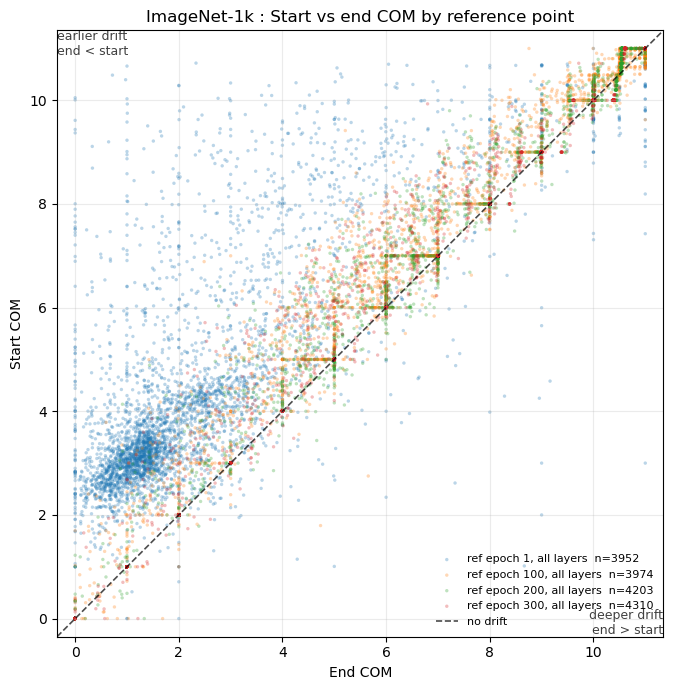

In [14]:
groups = [
    {
        "name": "ref epoch 1, all layers",
        "reference_epochs": [0],
        "reference_layers": np.arange(12),
    },
    {
        "name": "ref epoch 100, all layers",
        "reference_epochs": [100],
        "reference_layers": np.arange(12),
    },
    {
        "name": "ref epoch 200, all layers",
        "reference_epochs": [200],
        "reference_layers": np.arange(12),
    },
    {
        "name": "ref epoch 300, all layers",
        "reference_epochs": [299],
        "reference_layers": np.arange(12),
    },
]

score_kwargs = dict(
    posterior="softmax",
    beta=12.0,
    onset_k=3,
    disappearance_k=5,

    start_end_fraction=0.05,
    stickiness_radius=1.0,
    reference_stickiness_radius=1.0,
    drift_threshold_layers=1,
    min_directional_efficiency=0.00,
    min_layer_localization=0.5,
    sticky_threshold=0.70,
    sticky_max_abs_drift_layers=0.50,
    eps=1e-12,
    max_width=5,
)

group_dfs, all_df = collect_start_end_com_scores(
    groups,
    data_source_fn=data_source,
    compute_fn=compute_concept_scores,
    concept_filter_fn=lambda stats, S: stats[:, 0] > 0.001,
    layer_values_fn=lambda S: np.arange(S.shape[1]),
    score_kwargs=score_kwargs,
    data_path = "./results/vit_in1k_s8/subset",###evo_patterns
)
seed = "_s8"
tag = "com_all"

fig, ax = plot_start_end_com_scatter(
    group_dfs,
    start_col="drift_start_com",
    end_col="drift_end_com",
    size=6,
    alpha=0.30,
    title="ImageNet-1k : Start vs end COM by reference point",
    layer_min=0,
    layer_max=11,
    savepath= f"./paper_figs/scatter_{tag}{seed}.png", 
)